In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = [10,5]
import warnings
warnings.simplefilter(action = "ignore", category = FutureWarning)

In [34]:
df = pd.read_csv("titanic_cleaned.csv")

In [35]:
df.shape

(889, 9)

In [36]:
df.head(5)

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Age       889 non-null    float64
 3   SibSp     889 non-null    int64  
 4   Parch     889 non-null    int64  
 5   Fare      889 non-null    float64
 6   male      889 non-null    int64  
 7   Q         889 non-null    int64  
 8   S         889 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.6 KB


In [38]:
x = df.drop("Survived", axis = 1)
y = df["Survived"]

In [39]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = .20, random_state = 101)

In [40]:
print("x train", x_train.shape)
print("y train", y_train.shape)

print("--------------------------")

print("x test", x_test.shape)
print("y test", y_test.shape)

x train (711, 8)
y train (711,)
--------------------------
x test (178, 8)
y test (178,)


In [41]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

LogisticRegression()

In [42]:
from sklearn.metrics import accuracy_score
y_pred_log_reg = log_reg.predict(x_test)

print("Logistic Regression")
print("-----------------")

log_reg_accuracy = round(accuracy_score(y_test, y_pred_log_reg) * 100,2)
print("Accuracy", log_reg_accuracy, "%")

Logistic Regression
-----------------
Accuracy 82.02 %


Precision: 0.85
Recall: 0.66
------------------------------------------------------------
[[99  8]
 [24 47]]


<Axes: >

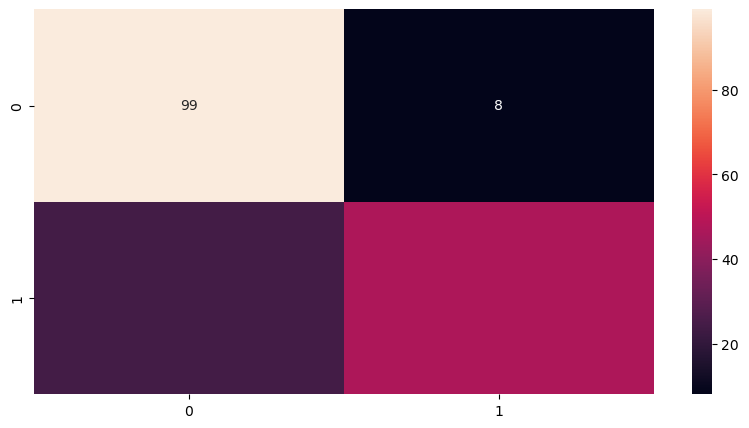

In [43]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
precision = precision_score(y_test, y_pred_log_reg)
recall = recall_score(y_test, y_pred_log_reg)

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall :.2f}')
print("--" * 30)

confusion = confusion_matrix(y_test, y_pred_log_reg)
print(confusion)
sns.heatmap(confusion, annot = True, fmt = "d")

In [44]:
from sklearn.tree import DecisionTreeClassifier
print("Decision Tree Classifier")
Dtree = DecisionTreeClassifier()
Dtree.fit(x_train, y_train)

Decision Tree Classifier


DecisionTreeClassifier()

In [45]:
from sklearn.metrics import accuracy_score
y_pred_Dtree = Dtree.predict(x_test)
print("Decision Tree Classifier")
print("--"*30)
Dtree_accuracy = round(accuracy_score(y_test, y_pred_Dtree) * 100,2)
print("Accuracy", Dtree_accuracy, "%")

Decision Tree Classifier
------------------------------------------------------------
Accuracy 79.78 %


Precison: 0.74
Recall:  0.76
------------------------------------------------------------


<Axes: >

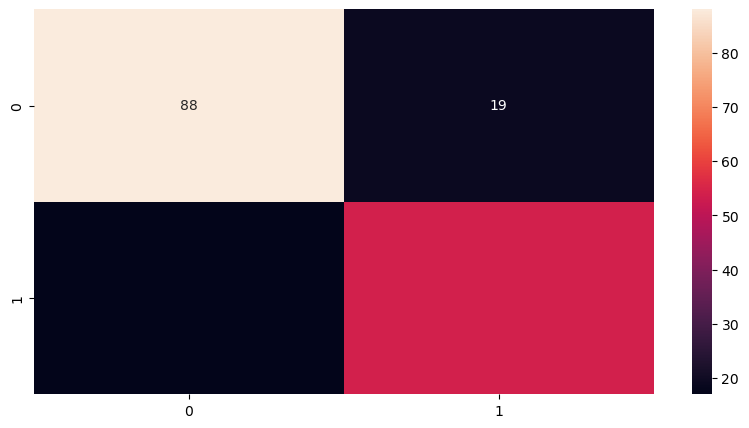

In [46]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
precision = precision_score(y_test, y_pred_Dtree)
recall = recall_score(y_test, y_pred_Dtree)
Dtree_accuracy = round(accuracy_score(y_test, y_pred_Dtree) * 100,2)

print(f'Precison: {precision:.2f}')
print(f'Recall: {recall: .2f}')

print("--" * 30)

confusion = confusion_matrix(y_test, y_pred_Dtree)

sns.heatmap(confusion, annot = True, fmt = "d")

In [47]:
from sklearn.ensemble import RandomForestClassifier
print("Random Forest Classifier")
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

Random Forest Classifier


RandomForestClassifier()

In [48]:
from sklearn.metrics import accuracy_score
y_pred_rfc = rfc.predict(x_test)
print("Random Forest Classifier")
print("---" * 15)
rfc_accuracy = round(accuracy_score(y_test, y_pred_rfc) * 100,2)
print("Accuracy", rfc_accuracy, "%")

Random Forest Classifier
---------------------------------------------
Accuracy 83.15 %


Precision: 0.80
Recall: 0.76


<Axes: >

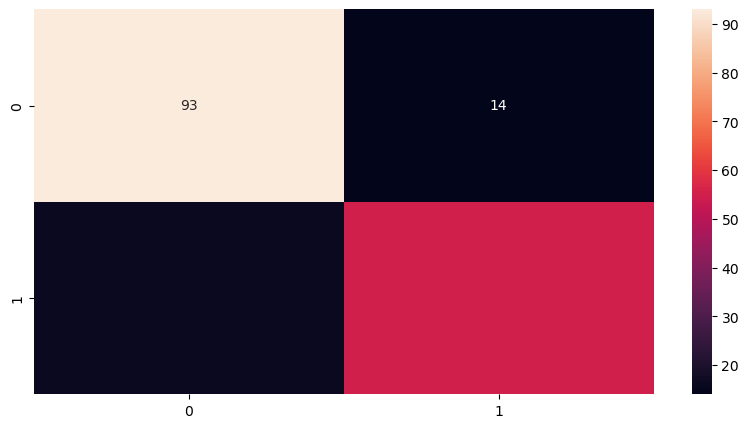

In [49]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
precision = precision_score(y_test, y_pred_rfc)

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

confusion = confusion_matrix(y_test, y_pred_rfc)
sns.heatmap(confusion, annot = True, fmt = "d")

In [50]:
from sklearn.ensemble import GradientBoostingClassifier

print("Gradient Boosting Classifier")

gbc = GradientBoostingClassifier()

gbc.fit(x_train, y_train)

Gradient Boosting Classifier


GradientBoostingClassifier()

In [51]:
from sklearn.metrics import accuracy_score
y_pred_gbc = gbc.predict(x_test)

print("Gradient Boosting Classifier")

print("--" * 15)

gbc_accuracy = round(accuracy_score(y_test, y_pred_gbc) * 100,2)

print("Accuracy", gbc_accuracy, "%")

Gradient Boosting Classifier
------------------------------
Accuracy 84.27 %


Precision : 0.83
Recall : 0.76
------------------------------


<Axes: >

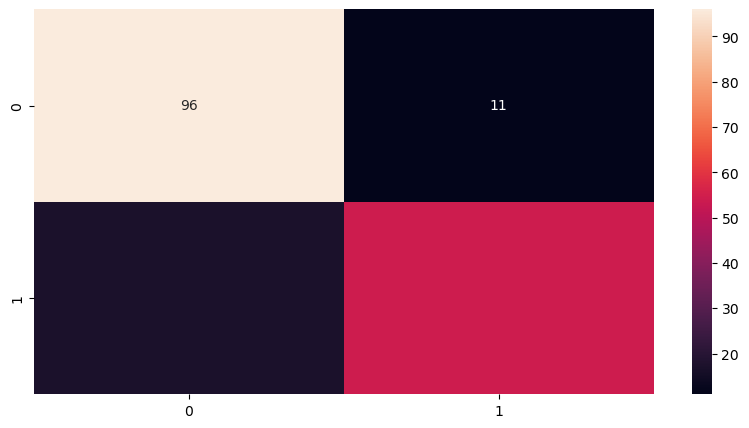

In [52]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
precision = precision_score(y_test, y_pred_gbc)
recall = recall_score(y_test, y_pred_gbc)

print(f'Precision : {precision:.2f}')
print(f'Recall : {recall:.2f}')
print("--" * 15)

confusion = confusion_matrix(y_test, y_pred_gbc)
sns.heatmap(confusion, annot = True, fmt = "d")

In [56]:
model_scores = {
    "Logistic Regression" : 82.02,
    "Decision Tree Regressor" : 79.78,
    "Random Forest Regressor" : 83.15,
    "Gradient Boosting Classifier" : 84.27
}

sorted_scores = sorted(model_scores.items(), key = lambda x: x[1], reverse = True)

print("Model Rankings(Greater values are better):")

for rank, (model_name, score) in enumerate(sorted_scores, start = 1):
    print(f'{rank}. {model_name} : {score}')

Model Rankings(Greater values are better):
1. Gradient Boosting Classifier : 84.27
2. Random Forest Regressor : 83.15
3. Logistic Regression : 82.02
4. Decision Tree Regressor : 79.78


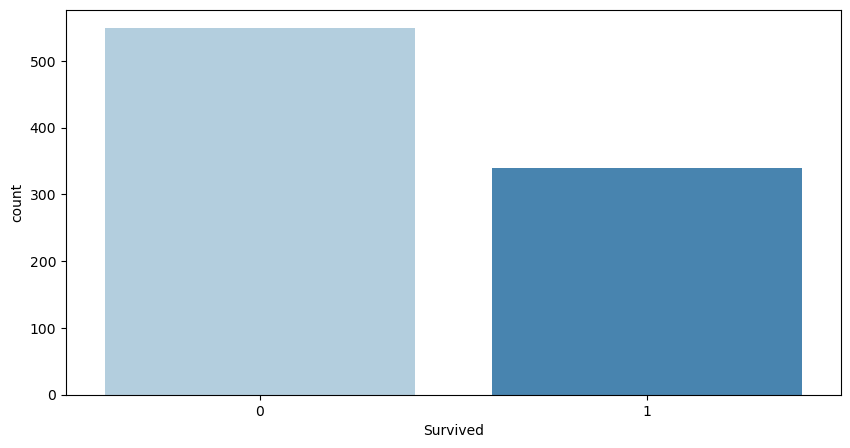

In [59]:
sns.countplot(x = "Survived", data = df, palette = "Blues");
plt.show()